In [63]:
import os
import scvi
import scanpy as sc
import sys
import numpy as np
import pandas as pd
import pickle
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Suppress the deprecation warning
scvi.settings.dl_pin_memory_gpu_training = False

n_latent = 100

ref_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/'
comb_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells/'
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_scvi/scvi.latent_%d/' % n_latent
os.makedirs(out_dir, exist_ok=True)

sample_df = pd.read_csv(ref_dir + 'Organoid_Sample_Description.txt', sep='\t',index_col=0)

/scratch/lsftmp/2228590.tmpdir/ipykernel_101837/2759929989.py:2: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  scvi.settings.dl_pin_memory_gpu_training = False


In [8]:
adata_fn = comb_dir + 'adata.combined.h5ad'
adata = sc.read_h5ad(adata_fn)

# Extract the matrix (CSR matrix)
mtx_fn = adata.X

# Extract genes and barcodes
g_fn = pd.Index(adata.var_names)
bc_fn = pd.Index(adata.obs_names)

# Use adata.X directly as the count matrix
mtx_fn = adata.X.A

norm_df = mtx_fn
norm_df = pd.DataFrame(norm_df, index=bc_fn, columns=g_fn)

In [21]:
print(g_fn)
print(bc_fn)
print(adata.obs)

Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1',
       'A2ML1-AS2', 'A3GALT2', 'A4GALT',
       ...
       'ZW10', 'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B',
       'ZYX', 'ZZEF1'],
      dtype='object', name='gene_name', length=32491)
Index(['125_P_HISC_ZFPKD_1_SEACell-149', '146_P_BASE_ZFPKD_1_SEACell-103',
       '125_P_HISC_ZFPKD_2_SEACell-219', '146_P_HISC_ZFPKD_2_SEACell-29',
       '146_P_BASE_ZFPKD_1_SEACell-125', '125_P_BASE_ZFPKD_2_SEACell-36',
       '146_P_HISC_ZFPKD_2_SEACell-104', '125_P_HISC_CTRL_1_SEACell-12',
       '146_P_BASE_CTRL_1_SEACell-241', '146_M_Dediff_ZFPKD_2_SEACell-42',
       ...
       '125_P_HISC_ZFPKD_1_SEACell-28', '146_M_Dediff_ZFPKD_1_SEACell-139',
       '125_P_BASE_ZFPKD_1_SEACell-58', '146_M_Dediff_CTRL_1_SEACell-120',
       '125_P_BASE_ZFPKD_2_SEACell-14', '146_P_BASE_ZFPKD_2_SEACell-46',
       '146_P_BASE_ZFPKD_1_SEACell-236', '146_P_BASE_ZFPKD_1_SEACell-254',
       '125_P_HISC_CTRL_1_SEACell-24

In [9]:
norm_df

gene_name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
125_P_HISC_ZFPKD_1_SEACell-149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,2.0,0.0,0.0,5.0,0.0,2.0,3.0,3.0
146_P_BASE_ZFPKD_1_SEACell-103,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,2.0,2.0,5.0
125_P_HISC_ZFPKD_2_SEACell-219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.0,17.0,21.0,0.0,1.0,45.0,0.0,17.0,13.0,22.0
146_P_HISC_ZFPKD_2_SEACell-29,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,6.0,0.0,6.0,0.0,0.0
146_P_BASE_ZFPKD_1_SEACell-125,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,15.0,31.0,1.0,0.0,12.0,0.0,12.0,3.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146_P_BASE_ZFPKD_2_SEACell-46,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,2.0,0.0,0.0,7.0,0.0,2.0,2.0,6.0
146_P_BASE_ZFPKD_1_SEACell-236,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0
146_P_BASE_ZFPKD_1_SEACell-254,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,2.0,1.0,1.0
125_P_HISC_CTRL_1_SEACell-249,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,5.0,3.0,1.0,0.0,7.0,0.0,4.0,4.0,6.0


In [13]:
samples = [re.sub('_[ACGT]+-1$','',i) for i in bc_fn]
samples = pd.Series(samples, index = bc_fn)
print(samples)

125_P_HISC_ZFPKD_1_SEACell-149    125_P_HISC_ZFPKD_1_SEACell-149
146_P_BASE_ZFPKD_1_SEACell-103    146_P_BASE_ZFPKD_1_SEACell-103
125_P_HISC_ZFPKD_2_SEACell-219    125_P_HISC_ZFPKD_2_SEACell-219
146_P_HISC_ZFPKD_2_SEACell-29      146_P_HISC_ZFPKD_2_SEACell-29
146_P_BASE_ZFPKD_1_SEACell-125    146_P_BASE_ZFPKD_1_SEACell-125
                                               ...              
146_P_BASE_ZFPKD_2_SEACell-46      146_P_BASE_ZFPKD_2_SEACell-46
146_P_BASE_ZFPKD_1_SEACell-236    146_P_BASE_ZFPKD_1_SEACell-236
146_P_BASE_ZFPKD_1_SEACell-254    146_P_BASE_ZFPKD_1_SEACell-254
125_P_HISC_CTRL_1_SEACell-249      125_P_HISC_CTRL_1_SEACell-249
146_P_HISC_ZFPKD_2_SEACell-228    146_P_HISC_ZFPKD_2_SEACell-228
Length: 3934, dtype: object


In [27]:
# Create a DataFrame with a column named 'Sample' and the unique samples
sample_df = pd.DataFrame({'Sample': samples.unique()})

# Set the index of the new DataFrame to 'Sample'
sample_df.set_index('Sample', inplace=True)

print(sample_df)

Empty DataFrame
Columns: []
Index: [125_P_HISC_ZFPKD_1_SEACell-149, 146_P_BASE_ZFPKD_1_SEACell-103, 125_P_HISC_ZFPKD_2_SEACell-219, 146_P_HISC_ZFPKD_2_SEACell-29, 146_P_BASE_ZFPKD_1_SEACell-125, 125_P_BASE_ZFPKD_2_SEACell-36, 146_P_HISC_ZFPKD_2_SEACell-104, 125_P_HISC_CTRL_1_SEACell-12, 146_P_BASE_CTRL_1_SEACell-241, 146_M_Dediff_ZFPKD_2_SEACell-42, 146_P_HISC_CTRL_1_SEACell-21, 125_P_HISC_CTRL_1_SEACell-142, 146_M_BASE_ZFPKD_2_SEACell-128, 125_P_BASE_ZFPKD_1_SEACell-149, 125_P_HISC_ZFPKD_2_SEACell-79, 146_M_Dediff_ZFPKD_1_SEACell-96, 125_P_HISC_CTRL_1_SEACell-18, 125_P_HISC_ZFPKD_1_SEACell-272, 125_P_HISC_ZFPKD_1_SEACell-115, 125_P_BASE_CTRL_1_SEACell-39, 146_P_HISC_ZFPKD_2_SEACell-91, 125_P_HISC_ZFPKD_1_SEACell-130, 146_P_BASE_ZFPKD_1_SEACell-110, 125_P_HISC_ZFPKD_1_SEACell-99, 146_P_BASE_ZFPKD_1_SEACell-205, 146_P_HISC_ZFPKD_2_SEACell-68, 146_P_HISC_ZFPKD_2_SEACell-33, 146_P_BASE_ZFPKD_1_SEACell-200, 146_M_Dediff_ZFPKD_2_SEACell-13, 125_P_HISC_ZFPKD_2_SEACell-175, 125_P_HISC_CTRL_1_

In [28]:
bc_intersect = adata.obs.index.intersection(norm_df.index)
g_intersect = adata.var_names.intersection(norm_df.columns)
adata = adata[bc_intersect, g_intersect]
adata.layers["counts"] = adata.X.copy()
norm_df = norm_df.loc[adata.obs.index, adata.var_names]

/scratch/lsftmp/2228590.tmpdir/ipykernel_101837/210728548.py:4: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [31]:
adata.X = norm_df.values
adata.layers['without_log'] = adata.X
adata.raw = adata
sc.pp.log1p(adata, base=2)
sample_df2 = sample_df.loc[samples,:]
sample_df2.index = adata.obs.index

In [32]:
adata.obs

,Patient,Tumor_Type,Culture_Media,ZFP_Expression,Sample_Name,Batch
125_P_HISC_ZFPKD_1_SEACell-149,125,Primary,HISC,ZFPKD,125_P_HISC_ZFPKD_1,1
146_P_BASE_ZFPKD_1_SEACell-103,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_1,5
125_P_HISC_ZFPKD_2_SEACell-219,125,Primary,HISC,ZFPKD,125_P_HISC_ZFPKD_2,1
146_P_HISC_ZFPKD_2_SEACell-29,146,Primary,HISC,ZFPKD,146_P_HISC_ZFPKD_2,6
146_P_BASE_ZFPKD_1_SEACell-125,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_1,5
...,...,...,...,...,...,...
146_P_BASE_ZFPKD_2_SEACell-46,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_2,5
146_P_BASE_ZFPKD_1_SEACell-236,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_1,5
146_P_BASE_ZFPKD_1_SEACell-254,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_1,5
125_P_HISC_CTRL_1_SEACell-249,125,Primary,HISC,CTRL,125_P_HISC_CTRL_1,1


In [34]:
adata.obs['Batch'] = adata.obs.Batch.astype(str).astype('category')

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    subset=True,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Batch"
)

scvi.model.SCVI.setup_anndata(
    adata,
    #layer="counts",
    batch_key = 'Batch',
    categorical_covariate_keys = ['Batch'],
    #continuous_covariate_keys=["mito_frac", "RBP_frac"]
    #continuous_covariate_keys=["mito_frac"]
)

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:61: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/home/forsythb/anaconda3/envs/scvi/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [35]:
model = scvi.model.SCVI(adata, n_latent = n_latent)

model

model.train()

model.save(out_dir + "my_model/")

latent = model.get_latent_representation()

adata.obsm["X_scVI"] = latent

denoised = model.get_normalized_expression(adata, library_size=1e4)

adata.layers["scvi_normalized"] = model.get_normalized_expression(
    library_size=10e4
)
        
adata.write_h5ad(out_dir + 'adata.scvi.latent_%d.h5ad' % n_latent)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

/home/forsythb/anaconda3/envs/scvi/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
/home/forsythb/anaconda3/envs/scvi/lib/python3.9/site-packages/scvi/module/_vae.py:477: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 2/400:   0%|          | 1/400 [00:01<12:54,  1.94s/it, v_num=1, train_loss_step=6.37e+3, train_loss_epoch=7.07e+3]

/home/forsythb/anaconda3/envs/scvi/lib/python3.9/site-packages/scvi/module/_vae.py:477: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/home/forsythb/anaconda3/envs/scvi/lib/python3.9/site-packages/scvi/module/_vae.py:477: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 400/400: 100%|██████████| 400/400 [01:49<00:00,  3.69it/s, v_num=1, train_loss_step=3.78e+3, train_loss_epoch=3.85e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:49<00:00,  3.65it/s, v_num=1, train_loss_step=3.78e+3, train_loss_epoch=3.85e+3]


In [46]:
# Set directories
mode='combined'
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_scvi/scvi.latent_100/'
os.makedirs(out_dir,exist_ok=True)

In [47]:
ifile = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_scvi/scvi.latent_100/adata.scvi.latent_100.h5ad'
adata = sc.read_h5ad(ifile)
adata.raw = adata

bc_intersect = adata.obs.index.intersection(norm_df.index)
g_intersect = adata.var_names.intersection(norm_df.columns)
adata = adata[bc_intersect, g_intersect]

norm_df = norm_df.loc[adata.obs.index, adata.var_names]

adata.X = norm_df.values
adata.layers['without_log'] = adata.X

#adata.X = np.log2(adata.X+1)
sc.pp.log1p(adata, base = 2)

sample_df2 = sample_df.loc[samples,:]
sample_df2.index = adata.obs.index

/scratch/lsftmp/2228590.tmpdir/ipykernel_101837/123086963.py:12: ImplicitModificationWarning: Setting element `.layers['without_log']` of view, initializing view as actual.
  adata.layers['without_log'] = adata.X


In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)
    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [49]:
'''
PCA
'''
# norm_df = pd.DataFrame(adata.X, index=adata.obs_names, columns = adata.var_names)

# bad_genes = norm_df.columns.str.contains(
#     "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
# norm_df = norm_df.loc[:,~bad_genes]

# Remove bad genes
bad_genes = adata.var_names.str.contains("^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
good_genes = ~bad_genes
norm_df = pd.DataFrame(adata.X[:, good_genes], index=adata.obs_names, columns=adata.var_names[good_genes])
adata = adata[:, good_genes]

print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values
adata.uns['num_components'] = num_components
adata.uns['var_explained'] = var_explained

Performing PCA
# Components = 43
Variance explained = 0.628802


/scratch/lsftmp/2228590.tmpdir/ipykernel_101837/770523328.py:32: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values


In [50]:
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])


Performing nearest neighbors


In [51]:
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata.obs['phenograph'] = clusters_merge.loc[adata.obs_names].astype('str').astype('category')

Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.8014931678771973 seconds
Jaccard graph constructed in 5.783862829208374 seconds
Wrote graph to binary file in 0.04146528244018555 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.907765
Louvain completed 21 runs in 1.9963147640228271 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 13.13095235824585 seconds


In [52]:
'''
LEIDEN CLUSTERING
'''
print('Leiden Clustering')
sc.tl.leiden(adata, resolution = 1.8)


Leiden Clustering


In [53]:
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata, groups = 'phenograph')
sc.pl.paga(adata, plot=False)

sc.tl.umap(adata, init_pos='paga', min_dist=min_dist)


Performing UMAP


In [54]:
'''
DIFFUSION MAP
'''
print('Performing Diffusion Map')
sc.tl.diffmap(adata, n_comps = 20)


Performing Diffusion Map


In [55]:
'''
DEG
'''
stats = {}
# Log-transform the count data
#sc.pp.log1p(adata, base=2)

# Perform DEG analysis
print('Performing DEG')
sc.tl.rank_genes_groups(adata, groupby='phenograph', method='wilcoxon')
# stats[group_name, 'logfoldchanges'] = np.log2(
#     pd.concat(stats[group_name, 'scale1'], axis=1)
# )

Performing DEG


/home/forsythb/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

In [56]:
ofile = out_dir + 'adata.combined.postprocessing.h5ad'
adata.write_h5ad(ofile)

adata.obs.to_csv(out_dir + 'obs.combined.postprocessing.csv', sep ='\t')

In [60]:
adata_no_scvi = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells/adata.combined.h5ad')
adata_scvi_100 = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_scvi/scvi.latent_100/adata.combined.postprocessing.h5ad')
adata_scvi = adata_no_scvi.copy()
adata_scvi.obsm['X_pca'] = adata_scvi_100.obsm['X_pca']
adata_scvi.obsm['X_umap'] = adata_scvi_100.obsm['X_umap']
adata_scvi.obsm['X_scVI'] = adata_scvi_100.obsm['X_scVI']
adata_scvi.uns['umap'] = adata_scvi_100.uns['umap']
adata_scvi.obs = adata_scvi_100.obs

In [61]:
adata_scvi

AnnData object with n_obs × n_vars = 3934 × 32491
    obs: 'Patient', 'Tumor_Type', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', '_scvi_batch', '_scvi_labels', 'phenograph', 'leiden'
    uns: 'umap'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    layers: 'raw'

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

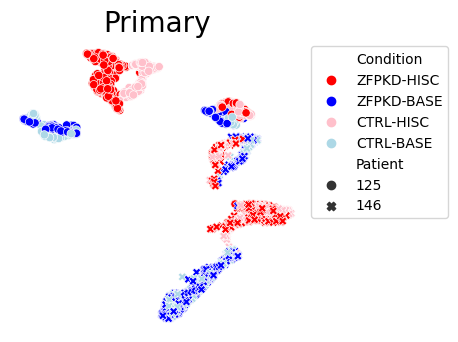

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

color_labels = {}
for col, i in zip(['blue', 'red'], ['CTRL', 'ZFPKD']):
    for shade, j in zip(['light', ''], ['BASE', 'HISC']):
        key = i + '-' + j
        color_labels[key] = shade + col
        if color_labels[key] == 'lightred':
            color_labels[key] = 'pink'

# Add missing keys
color_labels['ZFPKD-BASE'] = 'blue'  # Adjust the color as needed
color_labels['ZFPKD-HISC'] = 'red'  # Adjust the color as needed
color_labels['CTRL-BASE'] = 'lightblue'  # Adjust the color as needed
color_labels['CTRL-HISC'] = 'pink'  # Adjust the color as needed

fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8))

ind1 = adata_scvi.obs.Tumor_Type == 'Primary'
ind2 = adata_scvi.obs.Culture_Media != 'Dedifferentiated'
ind = ind1.values & ind2.values

adata = adata_scvi[ind, :]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:, ['Patient', 'Culture_Media', 'ZFP_Expression']]
plot_df['x'] = umap[:, 0].tolist()
plot_df['y'] = umap[:, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x', y='y', style='Patient', hue='Condition',
                    markers={'125': 'o', '146': 'X'},
                    palette=color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('Primary', fontsize=20)
plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Metastasis in Patient 146')

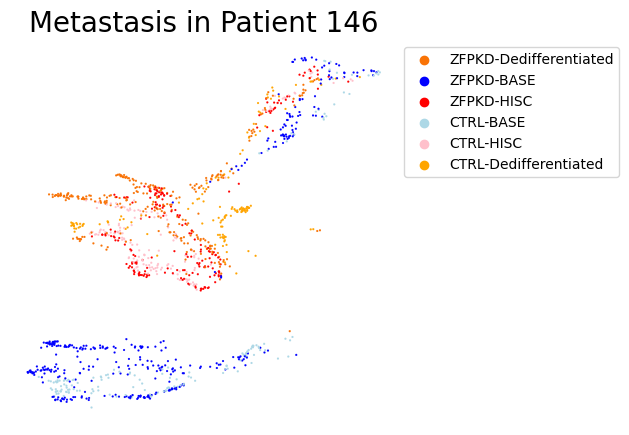

In [69]:
color_labels = {}
for col, j in zip(['blue','red','orange'],['BASE','HISC','Dedifferentiated']):
    for shade,i in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
        if color_labels[i + '-' + j] =='darkred':
            color_labels[i + '-' + j] = 'orange'
        if color_labels[i + '-' + j] =='lightorange':
            color_labels[i + '-' + j] = 'moccasin'

# Add missing keys
color_labels['ZFPKD-HISC'] = 'red'  
color_labels['ZFPKD-BASE'] = 'blue'  
color_labels['ZFPKD-Dedifferentiated'] = '#F97306'  
color_labels['CTRL-BASE'] = 'lightblue'  
color_labels['CTRL-HISC'] = 'pink'  
color_labels['CTRL-Dedifferentiated'] = '#FFA500'  # Adjust the color as needed

fig, ax=plt.subplots(1,1, figsize=(5,5))

ind = adata_scvi.obs.Tumor_Type=='Metastatic'
adata = adata_scvi[ind,:]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', hue='Condition',
                    s=2,edgecolor=None,
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Metastasis in Patient 146',fontsize=20)

In [70]:
adata_scvi

AnnData object with n_obs × n_vars = 3934 × 32491
    obs: 'Patient', 'Tumor_Type', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', '_scvi_batch', '_scvi_labels', 'phenograph', 'leiden'
    uns: 'umap'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    layers: 'raw'

In [72]:
ifile = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells/adata.combined.h5ad'
adata = sc.read_h5ad(ifile)
adata.raw = adata

bc_intersect = adata.obs.index.intersection(norm_df.index)
g_intersect = adata.var_names.intersection(norm_df.columns)
adata = adata[bc_intersect, g_intersect]

norm_df = norm_df.loc[adata.obs.index, adata.var_names]

adata.X = norm_df.values
adata.layers['without_log'] = adata.X

#adata.X = np.log2(adata.X+1)
sc.pp.log1p(adata, base = 2)

sample_df2 = sample_df.loc[samples,:]
sample_df2.index = adata.obs.index

/scratch/lsftmp/2228590.tmpdir/ipykernel_101837/2612022455.py:12: ImplicitModificationWarning: Setting element `.layers['without_log']` of view, initializing view as actual.
  adata.layers['without_log'] = adata.X


In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)
    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [80]:
norm_df

gene_name,AADACL2-AS1,AAMDC,AAMP,AARD,AASDHPPT,ABAT,ABCA13,ABCA4,ABCB1,ABCC9,...,ZNRD1,ZNRD2,ZNRF3,ZP2,ZPR1,ZRANB3,ZSCAN16-AS1,ZSCAN23,ZWILCH,ZWINT
125_P_HISC_ZFPKD_1_SEACell-149,1.000000,1.057275,1.083793,0.0,1.057275,0.000000,0.0,0.000000,1.099221,0.0,...,1.072961,1.040735,1.100346,0.0,1.057275,1.088043,0.000000,0.0,1.040735,1.040735
146_P_BASE_ZFPKD_1_SEACell-103,0.000000,1.057275,1.066700,0.0,1.066700,1.057275,0.0,0.000000,1.103023,1.0,...,0.000000,1.040735,1.105574,0.0,1.040735,1.072961,1.000000,0.0,0.000000,0.000000
125_P_HISC_ZFPKD_2_SEACell-219,1.086098,1.091171,1.097207,0.0,1.092458,1.080998,0.0,1.000000,1.112626,0.0,...,1.089714,1.089714,1.116596,0.0,1.072961,1.108410,1.088043,0.0,1.096425,1.099221
146_P_HISC_ZFPKD_2_SEACell-29,0.000000,1.000000,1.066700,0.0,1.077505,1.057275,1.0,0.000000,1.072961,0.0,...,1.077505,1.057275,1.098598,0.0,1.057275,1.066700,0.000000,0.0,1.000000,0.000000
146_P_BASE_ZFPKD_1_SEACell-125,0.000000,1.080998,1.100857,0.0,1.094636,1.040735,0.0,0.000000,1.108923,0.0,...,1.091171,1.092458,1.101794,1.0,1.083793,1.094636,1.057275,0.0,1.094636,1.103746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146_P_BASE_ZFPKD_2_SEACell-46,0.000000,1.040735,0.000000,0.0,0.000000,1.057275,0.0,1.072961,1.057275,0.0,...,0.000000,0.000000,1.104407,0.0,0.000000,1.086098,0.000000,0.0,1.057275,1.040735
146_P_BASE_ZFPKD_1_SEACell-236,0.000000,0.000000,0.000000,0.0,0.000000,1.040735,0.0,0.000000,1.077505,1.0,...,0.000000,0.000000,1.100857,0.0,0.000000,1.066700,0.000000,0.0,1.000000,0.000000
146_P_BASE_ZFPKD_1_SEACell-254,0.000000,0.000000,1.000000,0.0,1.072961,1.000000,0.0,0.000000,1.040735,0.0,...,0.000000,0.000000,1.093604,0.0,0.000000,1.040735,0.000000,0.0,0.000000,0.000000
125_P_HISC_CTRL_1_SEACell-249,1.040735,1.083793,1.088043,0.0,1.094636,1.040735,0.0,0.000000,1.102225,1.0,...,1.072961,1.088043,1.104407,0.0,1.077505,1.057275,1.077505,0.0,1.072961,1.057275


In [82]:
'''
PCA
'''
# norm_df = pd.DataFrame(adata.X, index=adata.obs_names, columns = adata.var_names)

# bad_genes = norm_df.columns.str.contains(
#     "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
# norm_df = norm_df.loc[:,~bad_genes]

# Remove bad genes
bad_genes = adata.var_names.str.contains("^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
good_genes = ~bad_genes
norm_df = pd.DataFrame(adata.X.tocsr().toarray()[:, good_genes], index=adata.obs_names, columns=adata.var_names[good_genes])
adata = adata[:, good_genes]

print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values
adata.uns['num_components'] = num_components

Performing PCA
# Components = 44
Variance explained = 0.621009


/scratch/lsftmp/2228590.tmpdir/ipykernel_101837/1193039465.py:32: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values


In [83]:
######################
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

######################
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata.obs['phenograph'] = clusters_merge.loc[adata.obs_names].astype('str').astype('category')

######################
'''
LEIDEN CLUSTERING
'''
print('Leiden Clustering')
sc.tl.leiden(adata, resolution = 1.8)

######################
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata, groups = 'phenograph')
sc.pl.paga(adata, plot=False)

sc.tl.umap(adata, init_pos='paga', min_dist=min_dist)


######################
'''
DIFFUSION MAP
'''
print('Performing Diffusion Map')
sc.tl.diffmap(adata, n_comps = 20)

######################
'''
DEG
'''
stats = {}
# Log-transform the count data
#sc.pp.log1p(adata, base=2)

# Perform DEG analysis
print('Performing DEG')
sc.tl.rank_genes_groups(adata, groupby='phenograph', method='wilcoxon')
# stats[group_name, 'logfoldchanges'] = np.log2(
#     pd.concat(stats[group_name, 'scale1'], axis=1)
# )

######################

Performing nearest neighbors
Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.6381447315216064 seconds
Jaccard graph constructed in 8.172194004058838 seconds
Wrote graph to binary file in 0.04223155975341797 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.906578
After 2 runs, maximum modularity is Q = 0.908356
After 4 runs, maximum modularity is Q = 0.909418
Louvain completed 24 runs in 4.264414072036743 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 20.714680910110474 seconds
Leiden Clustering
Performing UMAP
Performing Diffusion Map
Performing DEG


/home/forsythb/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:92: RuntimeWarning: overflow encountered in expm1
  self.expm1_func = lambda x: np.expm1(x * np.log(adata.uns['log1p']['base']))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/forsythb/.local/lib/python3.9/site-packages

In [90]:
adata_no_scvi

AnnData object with n_obs × n_vars = 3934 × 4837
    obs: 'Patient', 'Tumor_Type', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', 'phenograph', 'leiden'
    uns: 'diffmap_evals', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    layers: 'raw', 'without_log'
    obsp: 'connectivities', 'distances'

In [88]:
ofile = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.combined.postprocessing.h5ad'
adata.write_h5ad(ofile)

adata.obs.to_csv(out_dir + 'obs.combined.postprocessing.csv', sep ='\t')

In [89]:
adata_no_scvi = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.combined.postprocessing.h5ad')

In [99]:
adata_original = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells/adata.combined.h5ad')
adata_no_scvi = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.combined.postprocessing.h5ad')
adata = adata_original.copy()
adata.obsm['X_pca'] = adata_no_scvi.obsm['X_pca']
adata.obsm['X_umap'] = adata_no_scvi.obsm['X_umap']
adata.uns['umap'] = adata_no_scvi.uns['umap']
adata.obs = adata_no_scvi.obs

In [100]:
adata_no_sciv = adata
adata

AnnData object with n_obs × n_vars = 3934 × 32491
    obs: 'Patient', 'Tumor_Type', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', 'phenograph', 'leiden'
    uns: 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw'

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

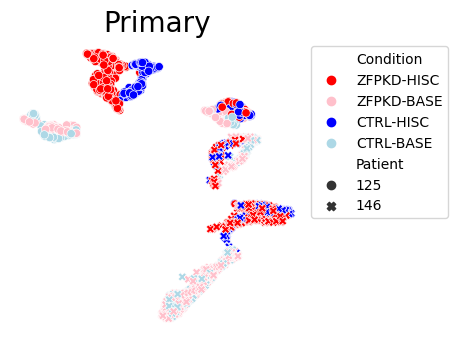

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

color_labels = {}
for col, i in zip(['blue', 'red'], ['CTRL', 'ZFPKD']):
    for shade, j in zip(['light', ''], ['BASE', 'HISC']):
        key = i + '-' + j
        color_labels[key] = shade + col
        if color_labels[key] == 'lightred':
            color_labels[key] = 'pink'

# # Add missing keys
# color_labels['ZFPKD-BASE'] = 'blue'  # Adjust the color as needed
# color_labels['ZFPKD-HISC'] = 'red'  # Adjust the color as needed
# color_labels['CTRL-BASE'] = 'lightblue'  # Adjust the color as needed
# color_labels['CTRL-HISC'] = 'pink'  # Adjust the color as needed

fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8))

ind1 = adata_scvi.obs.Tumor_Type == 'Primary'
ind2 = adata_scvi.obs.Culture_Media != 'Dedifferentiated'
ind = ind1.values & ind2.values

adata = adata_scvi[ind, :]

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:, ['Patient', 'Culture_Media', 'ZFP_Expression']]
plot_df['x'] = umap[:, 0].tolist()
plot_df['y'] = umap[:, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x', y='y', style='Patient', hue='Condition',
                    markers={'125': 'o', '146': 'X'},
                    palette=color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('Primary', fontsize=20)
plt.show()